In [1]:
import sys
sys.path.append('./scripts')
from calculos import processar_pipeline_dados

df_resultado = processar_pipeline_dados('data/capacitor_data.csv')

# Exibe a tabela resultante
df_resultado

,medida,d1_mm,d2_mm,d3_mm,c_medido_pf,sigma_c_medido_pf,d_media_mm,sigma_d_mm,w_m_inv,sigma_w_m_inv,c_cap_pf,sigma_c_cap_pf
0,1,8.3,8.5,9.5,30.2,0.8,8.766667,0.642910,114.068441,8.365294,25.7,0.943398
1,2,9.9,10.6,10.1,26.3,0.8,10.200000,0.360555,98.039216,3.465543,21.8,0.943398
2,3,12.1,13.9,14.4,22.4,0.7,13.466667,1.209683,74.257426,6.670393,17.9,0.860233
3,4,14.9,15.3,16.5,21.0,0.7,15.566667,0.832666,64.239829,3.436211,16.5,0.860233
4,5,16.5,17.8,18.0,19.6,0.7,17.433333,0.814453,57.361377,2.679816,15.1,0.860233
5,6,17.9,19.5,19.5,19.0,0.7,18.966667,0.923760,52.724077,2.567895,14.5,0.860233


In [3]:

from calculos import calcular_regressao_com_pesos, calcular_permissividade

# 1. Alimentando o modelo de regressão com a tabela processada
a, b, sigma_a, sigma_b = calcular_regressao_com_pesos(df_resultado)

# 2. Injetando o coeficiente 'a' para descobrir a permissividade
eps_0, sigma_eps_0 = calcular_permissividade(a, sigma_a)

# 3. Imprimindo o relatório na tela
print("=== RESULTADOS DO MODELO ESTATÍSTICO ===")
print(f"Coeficiente angular (a): {a:.3f} ± {sigma_a:.3f} pF·m")
print(f"Coeficiente linear (b): {b:.2f} ± {sigma_b:.2f} pF\n")

print("=== VALOR FÍSICO DESCOBERTO ===")
print(f"Permissividade do ar: {eps_0:.1f} ± {sigma_eps_0:.1f} pF/m")

=== RESULTADOS DO MODELO ESTATÍSTICO ===
Coeficiente angular (a): 0.178 ± 0.007 pF·m
Coeficiente linear (b): 4.94 ± 0.58 pF

=== VALOR FÍSICO DESCOBERTO ===
Permissividade do ar: 8.8 ± 0.4 pF/m


Matplotlib is building the font cache; this may take a moment.


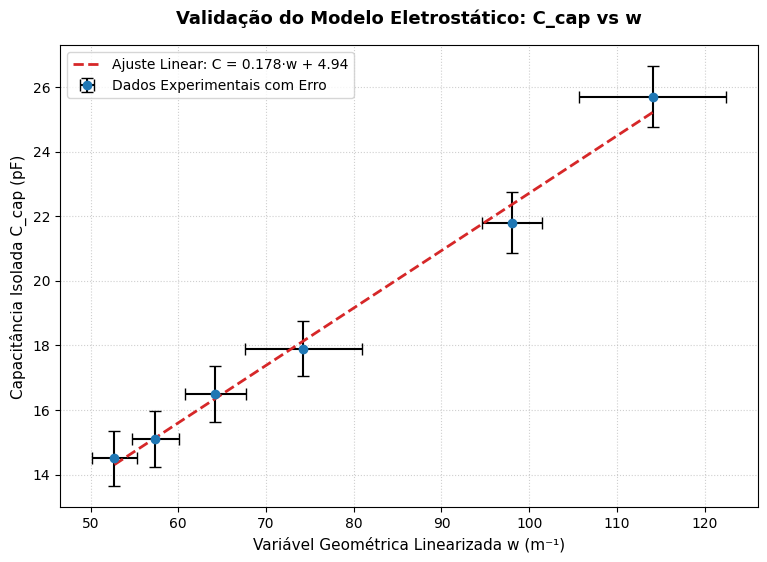

In [5]:
import matplotlib.pyplot as plt

# 1. Configurando o tamanho da imagem do gráfico
plt.figure(figsize=(9, 6))

# 2. Plotando os pontos experimentais com suas respectivas barras de erro
plt.errorbar(
    x=df_resultado['w_m_inv'], 
    y=df_resultado['c_cap_pf'], 
    xerr=df_resultado['sigma_w_m_inv'], 
    yerr=df_resultado['sigma_c_cap_pf'], 
    fmt='o', 
    color='#1f77b4', 
    ecolor='black', 
    capsize=4, 
    label='Dados Experimentais com Erro'
)

# 3. Criando e plotando a reta de tendência teórica (y = ax + b)
x_reta = df_resultado['w_m_inv']
y_reta = a * x_reta + b
plt.plot(
    x_reta, 
    y_reta, 
    color='#d62728', 
    linestyle='--', 
    linewidth=2, 
    label=f'Ajuste Linear: C = {a:.3f}·w + {b:.2f}'
)

# 4. Customização de eixos, títulos e legenda
plt.xlabel('Variável Geométrica Linearizada w (m⁻¹)', fontsize=11)
plt.ylabel('Capacitância Isolada C_cap (pF)', fontsize=11)
plt.title('Validação do Modelo Eletrostático: C_cap vs w', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Exibindo o gráfico finalizado
plt.show()

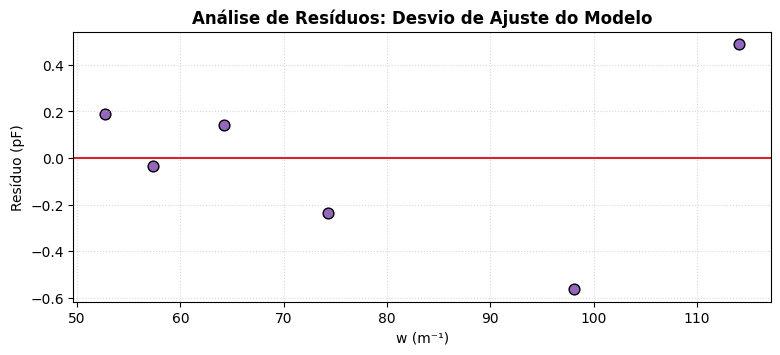

In [6]:
# Calculando a previsão do modelo e extraindo o resíduo (erro de ajuste)
y_predito = a * df_resultado['w_m_inv'] + b
residuos = df_resultado['c_cap_pf'] - y_predito

plt.figure(figsize=(9, 3.5))
# Linha horizontal no zero indicando o ajuste perfeito
plt.axhline(0, color='#d62728', linestyle='-', linewidth=1.5)

# Plotando os desvios
plt.scatter(df_resultado['w_m_inv'], residuos, color='#9467bd', edgecolors='black', s=60)

plt.xlabel('w (m⁻¹)', fontsize=10)
plt.ylabel('Resíduo (pF)', fontsize=10)
plt.title('Análise de Resíduos: Desvio de Ajuste do Modelo', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

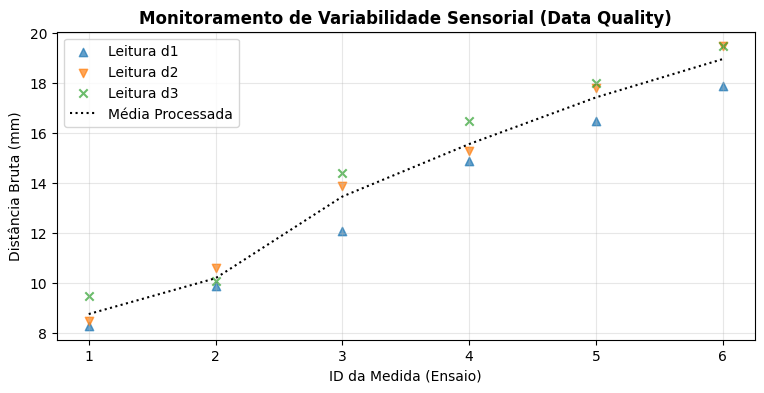

In [7]:
plt.figure(figsize=(9, 4))
medidas = df_resultado['medida']

# Plotando os três conjuntos de pontos brutos coletados na bancada
plt.scatter(medidas, df_resultado['d1_mm'], label='Leitura d1', alpha=0.7, marker='^')
plt.scatter(medidas, df_resultado['d2_mm'], label='Leitura d2', alpha=0.7, marker='v')
plt.scatter(medidas, df_resultado['d3_mm'], label='Leitura d3', alpha=0.7, marker='x')

# Desenhando uma linha passando pela média calculada
plt.plot(medidas, df_resultado['d_media_mm'], color='black', linestyle=':', label='Média Processada')

plt.xlabel('ID da Medida (Ensaio)', fontsize=10)
plt.ylabel('Distância Bruta (mm)', fontsize=10)
plt.title('Monitoramento de Variabilidade Sensorial (Data Quality)', fontsize=12, fontweight='bold')
plt.xticks(medidas)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ==========================================
# ETAPA DE LOAD (CARGA DOS DADOS)
# ==========================================
# Exportando o DataFrame enriquecido para um ficheiro CSV final.
# Usamos index=False para não exportar a coluna de numeração automática do Pandas.
# Mantemos o sep=';' para que o Excel em português o abra perfeitamente.

caminho_final = 'data/capacitor_processado.csv'
df_resultado.to_csv(caminho_final, index=False, sep=';')

print(f"Sucesso! O ficheiro final foi guardado em: {caminho_final}")